In [2]:
import torch
import torch.nn as nn  # Neural network module
import matplotlib.pyplot as plt  # For plotting

In [3]:
torch.manual_seed(71)  # For reproducibility
X=torch.linspace(1,50,50).reshape(-1,1)
e=torch.randint(-8,9,(50,1),dtype=torch.float)
y=2*X+1+e

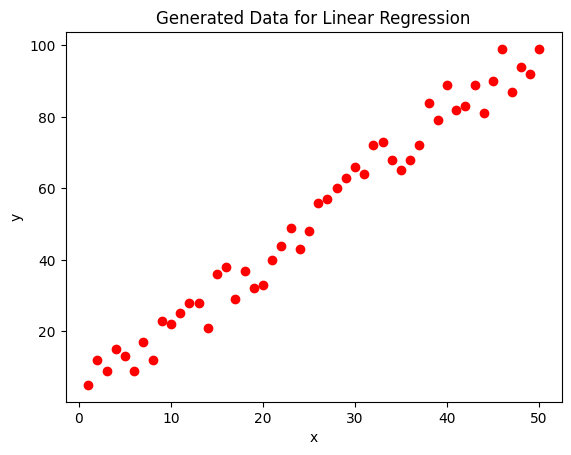

In [4]:
# Plot the original data
plt.scatter(X, y, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data for Linear Regression')
plt.show()

In [5]:
# Define the Linear Model Class
class Model(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear=nn.Linear(in_features,out_features)

    def forward(self, x):
        return self.linear(x)

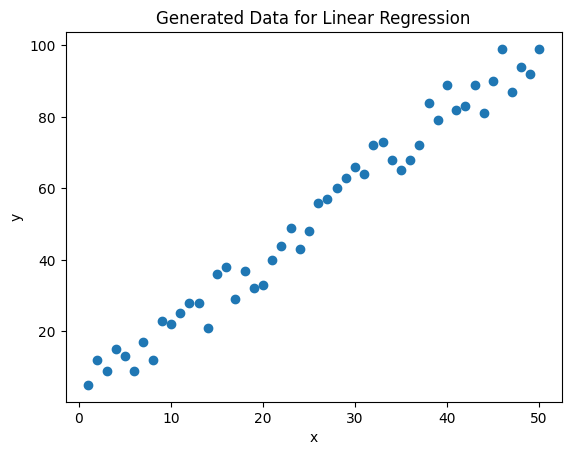

In [6]:
plt.scatter(X.numpy(), y.numpy())
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data for Linear Regression')
plt.show()

In [7]:
class Model(nn.Module):
    
    def __init__(self,in_features,out_features):
        super().__init__()
        
        self.linear = nn.Linear(in_features,out_features)
        
    def forward(self,x):
        y_pred = self.linear(x)
        return y_pred

In [8]:
# Initialize the Model
torch.manual_seed(59)  # Ensure same initial weights
model = Model(1, 1)

In [9]:
# Print Initial Weights and Bias
initial_weight = model.linear.weight.item()
initial_bias = model.linear.bias.item()
print("\nName: Purusothaman K")
print("Register No: 212224110046")
print(f'Initial Weight: {initial_weight:.8f}, Initial Bias: {initial_bias:.8f}\n')


Name: Purusothaman K
Register No: 212224110046
Initial Weight: 0.10597813, Initial Bias: 0.96379614



In [10]:
# Define Loss Function & Optimizer
loss_function=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.001)


In [ ]:
# Train the Model
epochs = 100
losses = []

for epoch in range(1, epochs + 1):  # Loop over epochs
    optimizer.zero_grad()
    y_pred=model(X)
    loss=loss_function(y_pred,y)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

    # Print loss, weight, and bias for EVERY epoch
    print(f'epoch: {epoch:2}  loss: {loss.item():10.8f}  '
          f'weight: {model.linear.weight.item():10.8f}  '
          f'bias: {model.linear.bias.item():10.8f}')


In [ ]:
# Final Weights & Bias
final_weight = model.linear.weight.item()
final_bias = model.linear.bias.item()
print(f'\nFinal Weight: {final_weight:.8f}, Final Bias: {final_bias:.8f}')

In [ ]:
#  Best-Fit Line Calculation
x1 = torch.tensor([X.min().item(), X.max().item()]) # Find min and max values of X
y1 = x1 * final_weight + final_bias # Compute corresponding y-values using trained model

In [ ]:
# Plot Original Data & Best-Fit Line
plt.scatter(X, y, label="Original Data")
plt.plot(x1, y1, 'r', label="Best-Fit Line")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trained Model: Best-Fit Line')
plt.legend()
plt.show()

In [17]:
# Prediction for x = 120
x_new = torch.tensor([[120.0]])  # New input as a tensor
y_new_pred = model(x_new).item()  # Predict using trained model